**Main imports**

In [1]:
import os
import requests
from tqdm import tqdm
import zipfile
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
from IPython import display as disp

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print('Imports complete.')

Imports complete.


**Download dataset**

In [2]:
# URL of the file
url = 'https://data.ncl.ac.uk/ndownloader/articles/24574354/versions/1'

# make directory if it doesn't exist
directory = 'classification-data'
if not os.path.exists(directory):
    os.makedirs(directory)

# where to save the downloaded file
file_path = os.path.join(directory, 'downloaded_file.zip')

# send a GET request to the URL with stream=True for chunked download
response = requests.get(url, stream=True)

# check if the request was successful
if response.status_code == 200:
    # total size in bytes from the header
    total_size = int(response.headers.get('content-length', 0))

    # progress bar
    with open(file_path, 'wb') as file, tqdm(
            desc="Downloading",
            total=total_size,
            unit='B',
            unit_scale=True,
            unit_divisor=1024,
    ) as progress_bar:
        for chunk in response.iter_content(chunk_size=1024):
            if chunk:
                file.write(chunk)
                progress_bar.update(len(chunk))

    print("File downloaded successfully!")

    # unzipping
    with zipfile.ZipFile(file_path, 'r') as zip_ref:
        zip_ref.extractall(directory)
        print(f"Files unzipped successfully in the '{directory}' directory!")

    # remove the zip file after extraction
    os.remove(file_path)
    print("Zip file removed after extraction.")

else:
    print(f"Failed to download the file. Status code: {response.status_code}")

**Import dataset**

In [3]:
import os
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# directory where the data is stored
data_dir = 'classification-data'

# the .npy files
train_x_path = os.path.join(data_dir, 'train_x.npy')
train_y_path = os.path.join(data_dir, 'train_y.npy')
valid_x_path = os.path.join(data_dir, 'valid_x.npy')
valid_y_path = os.path.join(data_dir, 'valid_y.npy')
test_x_path = os.path.join(data_dir, 'test_x.npy')
test_y_path = os.path.join(data_dir, 'test_y.npy')

# load the data
print("Loading data...")
train_x = np.load(train_x_path)
train_y = np.load(train_y_path)
valid_x = np.load(valid_x_path)
valid_y = np.load(valid_y_path)
test_x = np.load(test_x_path)
test_y = np.load(test_y_path)
print("Data loaded successfully.")

# convert NumPy arrays to PyTorch tensors
train_x = torch.from_numpy(train_x).float()
train_y = torch.from_numpy(train_y).long()
valid_x = torch.from_numpy(valid_x).float()
valid_y = torch.from_numpy(valid_y).long()
test_x = torch.from_numpy(test_x).float()
test_y = torch.from_numpy(test_y).long()

# create TensorDataset instances
train_dataset = TensorDataset(train_x, train_y)
valid_dataset = TensorDataset(valid_x, valid_y)
test_dataset = TensorDataset(test_x, test_y)

# batch size
batch_size = 128

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=False)

# Helper function to cycle through the data indefinitely
def cycle(iterable):
    while True:
        for x in iterable:
            yield x

# iterators for training, validation, and test loaders
train_iterator = iter(cycle(train_loader))
valid_iterator = iter(cycle(valid_loader))
test_iterator = iter(cycle(test_loader))

# class names
class_names = [str(i) for i in range(20)]

# dataset sizes
print(f'> Size of training dataset: {len(train_dataset)}')
print(f'> Size of validation dataset: {len(valid_dataset)}')
print(f'> Size of test dataset: {len(test_dataset)}')


Loading data...
Data loaded successfully.
> Size of training dataset: 45000
> Size of validation dataset: 15000
> Size of test dataset: 10000


**View some of the test dataset**

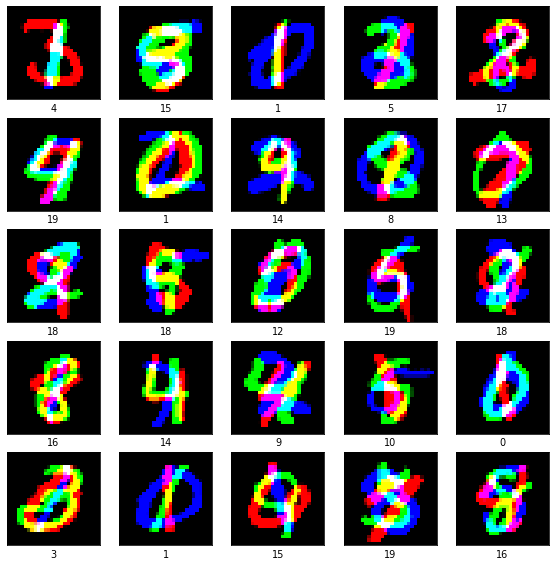

In [4]:
plt.rcParams['figure.dpi'] = 70
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    img = test_loader.dataset[i][0].numpy().transpose(1, 2, 0)
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.xlabel(class_names[test_loader.dataset[i][1]])
plt.show()

In [5]:
!pip install optuna

**SqueezeNet-inspired CNN** architecture and employs Optuna for hyperparameter tuning to optimize the learning rate, dropout rate, activation function, and pooling type. It also integrates weight decay for regularization and a cosine annealing learning rate scheduler to enhance training efficiency and model performance.

In [6]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import numpy as np
# import matplotlib.pyplot as plt
# from IPython import display as disp
# import optuna

# # this is the fire module, a core part of squeezenet's architecture
# class FireModule(nn.Module):
#     def __init__(self, in_channels, squeeze_channels, expand_channels, activation_fn):
#         super(FireModule, self).__init__()
#         self.activation_fn = activation_fn
#         self.squeeze = nn.Conv2d(in_channels, squeeze_channels, kernel_size=1)
#         self.squeeze_bn = nn.BatchNorm2d(squeeze_channels)

#         self.expand1x1 = nn.Conv2d(squeeze_channels, expand_channels, kernel_size=1)
#         self.expand3x3 = nn.Conv2d(squeeze_channels, expand_channels, kernel_size=3, padding=1)

#         self.expand_bn1 = nn.BatchNorm2d(expand_channels)
#         self.expand_bn2 = nn.BatchNorm2d(expand_channels)

#     def forward(self, x):
#         x = self.activation_fn(self.squeeze_bn(self.squeeze(x)))
#         return self.activation_fn(torch.cat([
#             self.expand_bn1(self.expand1x1(x)),
#             self.expand_bn2(self.expand3x3(x))
#         ], 1))

# # the main classifier inspired by squeezenet
# class SqueezeNetClassifier(nn.Module):
#     def __init__(self, params, activation_fn, pooling_fn, dropout_rate):
#         super(SqueezeNetClassifier, self).__init__()
#         self.activation_fn = activation_fn
#         self.pooling_fn = pooling_fn

#         self.conv1 = nn.Conv2d(params['n_channels'], 55, kernel_size=3, stride=1, padding=1)
#         self.bn1 = nn.BatchNorm2d(55)

#         # stack of fire modules
#         self.fire1 = FireModule(55, 27, 55, self.activation_fn)
#         self.fire2 = FireModule(110, 29, 56, self.activation_fn)
#         self.fire3 = FireModule(112, 34, 70, self.activation_fn)
#         self.fire4 = FireModule(140, 35, 70, self.activation_fn)

#         self.dropout = nn.Dropout(dropout_rate)
#         self.conv_final = nn.Conv2d(140, params['n_classes'], kernel_size=1)
#         self.gap = nn.AdaptiveAvgPool2d(1)

#     def forward(self, x):
#         x = self.activation_fn(self.bn1(self.conv1(x)))
#         x = self.fire1(x)
#         x = self.pooling_fn(x)

#         x = self.fire2(x)
#         x = self.pooling_fn(x)

#         x = self.fire3(x)
#         x = self.pooling_fn(x)

#         x = self.fire4(x)
#         x = self.dropout(x)

#         x = self.conv_final(x)
#         x = self.gap(x)
#         x = torch.flatten(x, 1)
#         return x

# # this function tunes the hyperparameters using optuna
# def objective(trial):
#     lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
#     dropout_rate = trial.suggest_float('dropout_rate', 0.3, 0.7)
#     activation_choice = trial.suggest_categorical('activation_fn', ['ReLU', 'LeakyReLU', 'ELU'])
#     pooling_choice = trial.suggest_categorical('pooling_fn', ['MaxPool2d', 'AvgPool2d'])

#     # choose activation function based on trial suggestion
#     if activation_choice == 'ReLU':
#         activation_fn = F.relu
#     elif activation_choice == 'LeakyReLU':
#         activation_fn = F.leaky_relu
#     else:
#         activation_fn = F.elu

#     # choose pooling layer
#     pooling_fn = getattr(nn, pooling_choice)(kernel_size=2, stride=2)

#     params = {'n_channels': 3, 'n_classes': 20}
#     model = SqueezeNetClassifier(params, activation_fn, pooling_fn, dropout_rate)
#     model.to(device)

#     optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-6)
#     criterion = nn.CrossEntropyLoss()

#     # quick training loop to test hyperparameters
#     model.train()
#     for batch_idx, (inputs, labels) in enumerate(train_loader):
#         inputs, labels = inputs.to(device), labels.to(device)
#         optimizer.zero_grad()
#         outputs = model(inputs)
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()
#         if batch_idx >= 5:
#             break

#     # validate the model
#     model.eval()
#     correct, total = 0, 0
#     with torch.no_grad():
#         for inputs, labels in valid_loader:
#             inputs, labels = inputs.to(device), labels.to(device)
#             outputs = model(inputs)
#             _, predicted = torch.max(outputs, 1)
#             total += labels.size(0)
#             correct += (predicted == labels).sum().item()
#             break

#     return correct / total

# # run optuna study to find the best hyperparameters
# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=20)

# # display best hyperparameters
# best_params = study.best_params
# print(f'Best hyperparameters: {best_params}')

# # use the best hyperparameters to set up the final model
# if best_params['activation_fn'] == 'ReLU':
#     activation_fn = F.relu
# elif best_params['activation_fn'] == 'LeakyReLU':
#     activation_fn = F.leaky_relu
# else:
#     activation_fn = F.elu

# pooling_fn = getattr(nn, best_params['pooling_fn'])(kernel_size=2, stride=2)

# params = {
#     'n_channels': 3,
#     'n_classes': 20
# }

# N = SqueezeNetClassifier(params, activation_fn, pooling_fn, best_params['dropout_rate']).to(device)

# # print out the total number of trainable parameters
# num_params = sum(p.numel() for p in N.parameters() if p.requires_grad)
# print(f'> Number of parameters {num_params}')

# if num_params > 100000:
#     print("> Warning: you have gone over your parameter budget and will have a grade penalty!")

# # set up the optimizer with the best learning rate
# optimiser = torch.optim.Adam(N.parameters(), lr=best_params['lr'], weight_decay=5e-6)

# # add a learning rate scheduler to adjust the learning rate over epochs
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=10)

# plot_data = []
# steps = 0

In the previous cell, we used **Optuna** for hyperparameter tuning and identified the **best parameters: learning rate (0.0035), dropout rate (0.34), ELU activation function, and AvgPool2d pooling**. In this cell, these optimal hyperparameters are fixed into the SqueezeNet-inspired model architecture to enhance training performance and ensure consistent results.

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from IPython import display as disp

# define the fire module for squeezenet
class FireModule(nn.Module):
    def __init__(self, in_channels, squeeze_channels, expand_channels):
        super(FireModule, self).__init__()
        self.squeeze = nn.Conv2d(in_channels, squeeze_channels, kernel_size=1)
        self.squeeze_bn = nn.BatchNorm2d(squeeze_channels)

        self.expand1x1 = nn.Conv2d(squeeze_channels, expand_channels, kernel_size=1)
        self.expand3x3 = nn.Conv2d(squeeze_channels, expand_channels, kernel_size=3, padding=1)

        self.expand_bn1 = nn.BatchNorm2d(expand_channels)
        self.expand_bn2 = nn.BatchNorm2d(expand_channels)

    def forward(self, x):
        x = F.elu(self.squeeze_bn(self.squeeze(x)))
        return F.elu(torch.cat([
            self.expand_bn1(self.expand1x1(x)),
            self.expand_bn2(self.expand3x3(x))
        ], 1))

# define the squeezenet-inspired classifier
class SqueezeNetClassifier(nn.Module):
    def __init__(self, params):
        super(SqueezeNetClassifier, self).__init__()
        self.conv1 = nn.Conv2d(params['n_channels'], 55, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(55)

        # fire modules with corrected input/output channels
        self.fire1 = FireModule(55, 27, 55)
        self.fire2 = FireModule(110, 29, 56)
        self.fire3 = FireModule(112, 34, 70)
        self.fire4 = FireModule(140, 35, 70)

        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.38)

        self.conv_final = nn.Conv2d(140, params['n_classes'], kernel_size=1)
        self.gap = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):
        x = F.elu(self.bn1(self.conv1(x)))
        x = self.fire1(x)
        x = self.pool(x)

        x = self.fire2(x)
        x = self.pool(x)

        x = self.fire3(x)
        x = self.pool(x)

        x = self.fire4(x)
        x = self.dropout(x)

        x = self.conv_final(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        return x

# hyperparameters
params = {
    'n_channels': 3,  # number of input channels (e.g., RGB images)
    'n_classes': 20   # number of output classes
}

# initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N = SqueezeNetClassifier(params).to(device)

# print the number of parameters
num_params = sum(p.numel() for p in N.parameters() if p.requires_grad)
print(f'> Number of parameters {num_params}')

if num_params > 100000:
    print("> Warning: you have gone over your parameter budget and will have a grade penalty!")

# initialize the optimizer with best learning rate
optimiser = torch.optim.Adam(N.parameters(), lr=0.0035)
plot_data = []
steps = 0

> Number of parameters 99124


**Main training and testing loop**

steps: 10000.00, train loss: 0.320, train acc: 0.897±0.029, test acc: 0.834±0.045


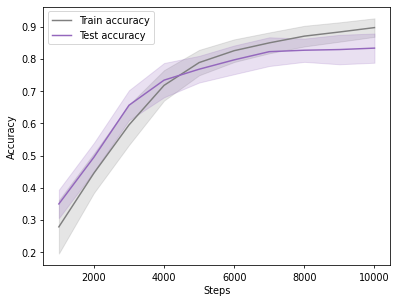

In [8]:
# Main training and testing loop
while (steps < 10000):

    # Arrays for metrics
    train_loss_arr = np.zeros(0)
    train_acc_arr = np.zeros(0)
    test_acc_arr = np.zeros(0)

    # Iterate through some of the train dataset
    for i in range(1000):
        x, t = next(train_iterator)
        x, t = x.to(device), t.to(device)

        optimiser.zero_grad()
        p = N(x)
        pred = p.argmax(dim=1, keepdim=True)
        loss = torch.nn.functional.cross_entropy(p, t)
        loss.backward()
        optimiser.step()
        steps += 1

        train_loss_arr = np.append(train_loss_arr, loss.cpu().data)
        train_acc_arr = np.append(train_acc_arr, pred.data.eq(t.view_as(pred)).float().mean().item())

    # Iterate over the entire test dataset
    for x, t in test_loader:
        x, t = x.to(device), t.to(device)
        p = N(x)
        loss = torch.nn.functional.cross_entropy(p, t)
        pred = p.argmax(dim=1, keepdim=True)
        test_acc_arr = np.append(test_acc_arr, pred.data.eq(t.view_as(pred)).float().mean().item())

    # Print your loss and accuracy data - include this in the final report
    print('steps: {:.2f}, train loss: {:.3f}, train acc: {:.3f}±{:.3f}, test acc: {:.3f}±{:.3f}'.format(
        steps, train_loss_arr.mean(), train_acc_arr.mean(), train_acc_arr.std(), test_acc_arr.mean(), test_acc_arr.std()))

    # Plot your accuracy graph - add a graph like this in your final report
    plot_data.append([steps, np.array(train_acc_arr).mean(), np.array(train_acc_arr).std(), np.array(test_acc_arr).mean(), np.array(test_acc_arr).std()])
    plt.plot([x[0] for x in plot_data], [x[1] for x in plot_data], '-', color='tab:grey', label="Train accuracy")
    plt.fill_between([x[0] for x in plot_data], [x[1]-x[2] for x in plot_data], [x[1]+x[2] for x in plot_data], alpha=0.2, color='tab:grey')
    plt.plot([x[0] for x in plot_data], [x[3] for x in plot_data], '-', color='tab:purple', label="Test accuracy")
    plt.fill_between([x[0] for x in plot_data], [x[3]-x[4] for x in plot_data], [x[3]+x[4] for x in plot_data], alpha=0.2, color='tab:purple')
    plt.xlabel('Steps')
    plt.ylabel('Accuracy')
    plt.legend(loc="upper left")
    plt.show()
    disp.clear_output(wait=True)


**Inference on dataset**

This is useful for analysis but is entirely optional

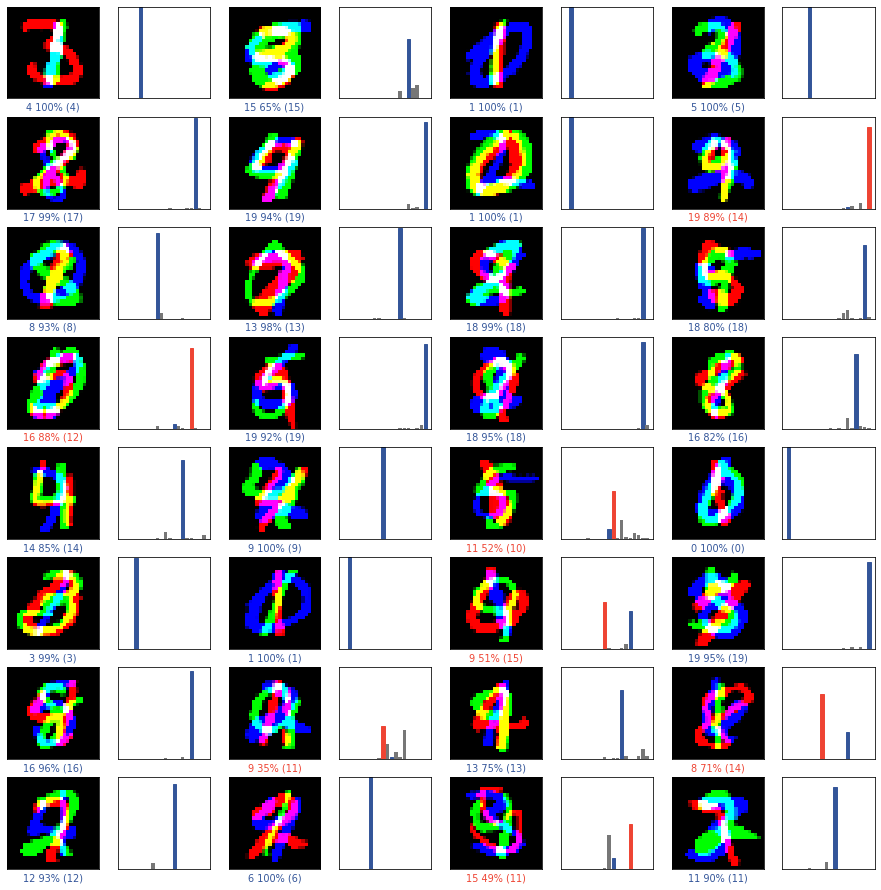

In [9]:
def plot_image(i, predictions_array, true_label, img):
    predictions_array, true_label, img = predictions_array[i], true_label[i], img[i]
    img = np.clip(img, 0, 1)
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    img = np.transpose(img, (1, 2, 0))
    plt.imshow(img)

    predicted_label = np.argmax(predictions_array)
    color = '#335599' if predicted_label == true_label else '#ee4433'

    plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                  100*np.max(predictions_array),
                                  class_names[true_label]),
                                  color=color)

def plot_value_array(i, predictions_array, true_label):
    predictions_array, true_label = predictions_array[i], true_label[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    thisplot = plt.bar(range(20), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)

    thisplot[predicted_label].set_color('#ee4433')
    thisplot[true_label].set_color('#335599')

test_images, test_labels = next(test_iterator)
test_images, test_labels = test_images.to(device), test_labels.to(device)
test_preds = torch.softmax(N(test_images), dim=1).data.cpu().numpy()
num_rows = 8
num_cols = 4
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, test_preds, test_labels.cpu().numpy(), test_images.cpu().numpy()) # Used .numpy() here
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, test_preds, test_labels.cpu().numpy())